In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.8 MB/s eta 0:00:00


In [ ]:
%matplotlib inline

In [ ]:
pip install pillow

In [ ]:
pip install matplotlib

In [ ]:
pip install scikit-learn

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import io

# --- মডেল আর্কিটেকচার (আপনার কোড থেকে হুবহু কপি করা) ---
# এই ক্লাসগুলো ডিফাইন করা আবশ্যক, নাহলে মডেল লোড হবে না।

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class RAGModel(nn.Module):
    def __init__(self, retrieval_database=None):
        super().__init__()
        self.retrieval_database = retrieval_database
    def retrieve_features(self, query_image):
        return torch.randn(query_image.size(0), 128).to(device)

class VisionLLM(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, context):
        return torch.randn(context.size(0), 128).to(device)

class CNNAttentionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.effnet_b0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.effnet_b3 = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        self.effnet_b5 = models.efficientnet_b5(weights=models.EfficientNet_B5_Weights.DEFAULT)
        self.effnet_b0.classifier = nn.Identity()
        self.effnet_b3.classifier = nn.Identity()
        self.effnet_b5.classifier = nn.Identity()
        embed_dim = 1280 + 1536 + 2048
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=8, batch_first=True)
    def forward(self, x):
        x_b0 = self.effnet_b0(x)
        x_b3 = self.effnet_b3(x)
        x_b5 = self.effnet_b5(x)
        combined_features = torch.cat((x_b0, x_b3, x_b5), dim=1)
        attention_input = combined_features.unsqueeze(1)
        attention_output, _ = self.attention(attention_input, attention_input, attention_input)
        return attention_output.squeeze(1)

class FusionClassificationModel(nn.Module):
    def __init__(self, num_classes, retrieval_model):
        super().__init__()
        self.retrieval_model = retrieval_model
        self.vision_llm = VisionLLM()
        self.cnn_attention = CNNAttentionModel()
        cnn_attention_output_size = 1280 + 1536 + 2048
        llm_output_size = 128
        self.fc = nn.Sequential(
            nn.Linear(llm_output_size + cnn_attention_output_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        rag_response = self.retrieval_model.retrieve_features(x)
        llm_features = self.vision_llm(rag_response)
        cnn_attention_features = self.cnn_attention(x)
        combined_features = torch.cat((llm_features, cnn_attention_features), dim=1)
        out = self.fc(combined_features)
        return out

# --- মডেল লোড করা ---
NUM_CLASSES = 7 # আপনার ক্লাসের সংখ্যা (Bacteria, Fungi, etc.)
MODEL_PATH = "/content/drive/MyDrive/final_fusion_Ricelast.pt" # আপনার সেভ করা মডেলের পাথ

# মডেল ইনিশিয়ালাইজ করুন
rag_model = RAGModel()
model = FusionClassificationModel(num_classes=NUM_CLASSES, retrieval_model=rag_model).to(device)

# সেভ করা weight লোড করুন
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval() # মডেলকে evaluation মোডে সেট করুন

print("✅ মডেল সফলভাবে লোড হয়েছে!")

✅ মডেল সফলভাবে লোড হয়েছে!


In [ ]:
# আপনার Classification Report অনুযায়ী ক্লাসগুলোর নাম দিন
class_names = ['Healthy', 'Insect', 'Leaf scald', 'Rice Tungro', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes']

# ইমেজ প্রসেসিং-এর জন্য Transform (ট্রেনিং-এর সময় যা ব্যবহার করেছেন)
transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

def predict_image(image_bytes):
    """
    এই ফাংশনটি একটি ইমেজ ইনপুট নেয় এবং প্রেডিকশন দেখায়।
    """
    # বাইটস থেকে ইমেজ লোড করুন
    image = Image.open(io.BytesIO(image_bytes)).convert('RGB')

    # ইনপুট ইমেজকে মডেলের জন্য প্রস্তুত করুন
    img_tensor = transform(image).unsqueeze(0).to(device)

    # প্রেডিকশন করুন
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)

    # প্রেডিক্টেড ক্লাস এবং কনফিডেন্স স্কোর বের করুন
    predicted_class = class_names[predicted_idx.item()]
    confidence_score = confidence.item() * 100

    # ইমেজ এবং রেজাল্ট দেখান
    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence_score:.2f}%")
    plt.axis('off')
    plt.show()

print("⚙️ প্রেডিকশন ফাংশন রেডি!")

⚙️ প্রেডিকশন ফাংশন রেডি!


Saving Augmented_0_180.jpeg to Augmented_0_180.jpeg
'Augmented_0_180.jpeg' ইমেজের জন্য প্রেডিকশন করা হচ্ছে...


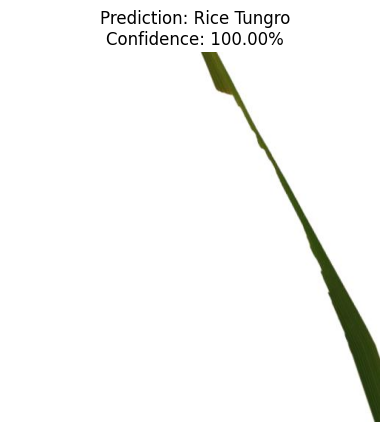

In [ ]:
# Colab-এর ফাইল আপলোড ফাংশন ব্যবহার করুন
uploaded = files.upload()

# আপলোড করা ফাইলটির ওপর প্রেডিকশন চালান
for file_name in uploaded.keys():
    print(f"'{file_name}' ইমেজের জন্য প্রেডিকশন করা হচ্ছে...")
    image_bytes = uploaded[file_name]
    predict_image(image_bytes)